# **Feature Engineering Overview**

The process of transforming and creating new features to make data better suited for a machine learning model.

### **The Goal & Purpose**

Make observed data more relevant to the target. 

eg:
- converting temperature and wind speed into "apparent temperature"

**Primary Benefits**:
- Boosts predictive performance.
- Minimizes computational/data requirements.
- Increases model interpretability.

## **The Guiding Principle**

- **Requirement**: For a feature to be effective, the model must be capable of learning its relationship to the target.

- **Model Limitations**: Linear models only recognize linear relationships. If the underlying data is non-linear (e.g., side length vs. area), you must manually transform the feature (e.g., squaring the length) to "uncover" that relationship for the model.

- **Core Idea**: Transformations act as an extension of the model’s capabilities.

### Example: Concrete Strength & Baselines
- **Baseline Testing**: Always evaluate a model on raw data first to establish a performance benchmark.
- **Synthetic Features**: In the concrete example, absolute ingredient amounts were less predictive than ratios (e.g., Water-to-Cement ratio).
- **Validation**: By adding these ratios, the Mean Absolute Error (MAE) dropped from 8.326 to 7.948, proving the engineered features provided information the model couldn't extract on its own.

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

df = pd.read_csv("../input/concrete.csv")
df.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [12]:
X = df.copy()
y = X.pop("CompressiveStrength")

baseline = RandomForestRegressor(criterion="absolute_error", random_state=0)
baseline_scores = cross_val_score(
    baseline, X, y, cv=5, scoring="neg_mean_absolute_error"
)

baseline_score = -1 * baseline_scores.mean()
print(f"MAE Baseline Score : {baseline_score:.4}")
print(baseline_scores)

MAE Baseline Score : 8.326
[ -8.09654733  -6.48560583  -6.19631019  -4.32259102 -16.52878835]


---

# **Mutual Information**

- Mutual Information measures how much predicts the target, when knowing the variable.
- MI = Reduction in uncertainty of the target when you know the feature.

eg:
- Knowing curb_weight makes you much more certain about price → High MI
- Knowing fuel_type doesn’t change your confidence much → Low MI
- If a feature tells nothing → MI = 0

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../input/autos.csv")
print(df.columns)
df.head()

Index(['symboling', 'make', 'fuel_type', 'aspiration', 'num_of_doors',
       'body_style', 'drive_wheels', 'engine_location', 'wheel_base', 'length',
       'width', 'height', 'curb_weight', 'engine_type', 'num_of_cylinders',
       'engine_size', 'fuel_system', 'bore', 'stroke', 'compression_ratio',
       'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price'],
      dtype='str')


,symboling,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9,111,5000,21,27,13495
1,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9,111,5000,21,27,16500
2,1,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9,154,5000,19,26,16500
3,2,audi,gas,std,4,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10,102,5500,24,30,13950
4,2,audi,gas,std,4,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8,115,5500,18,22,17450


In [26]:
X = df.copy()
y = X.pop("price")

for colName in X.select_dtypes("object"):
    X[colName], _ = X[colName].factorize()

discrete_features = X.dtypes == int

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11572\3711444900.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for colName in X.select_dtypes("object"):


In [27]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores[::3]

curb_weight          1.551320
highway_mpg          0.953367
length               0.606305
bore                 0.505347
stroke               0.379497
num_of_cylinders     0.332152
compression_ratio    0.132626
fuel_type            0.048120
Name: MI Scores, dtype: float64

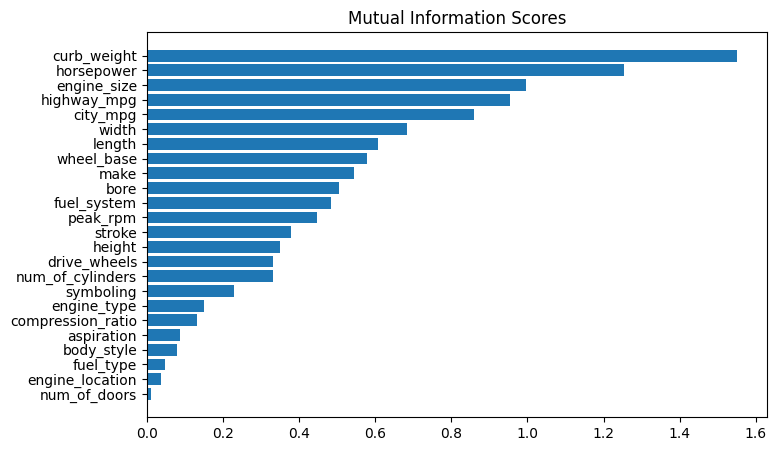

In [34]:
def plot_mi_scores(scores: pd.Series):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

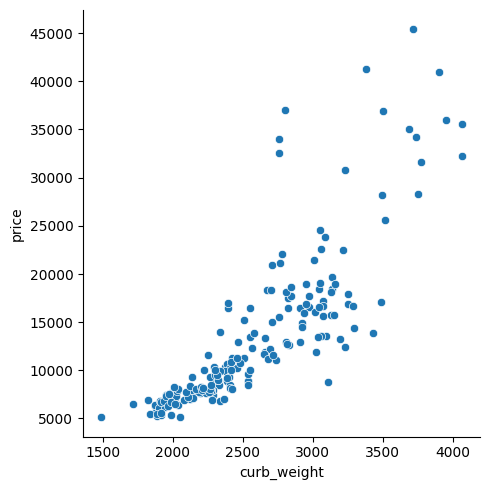

In [39]:
sns.relplot(x="curb_weight", y="price", data=df);

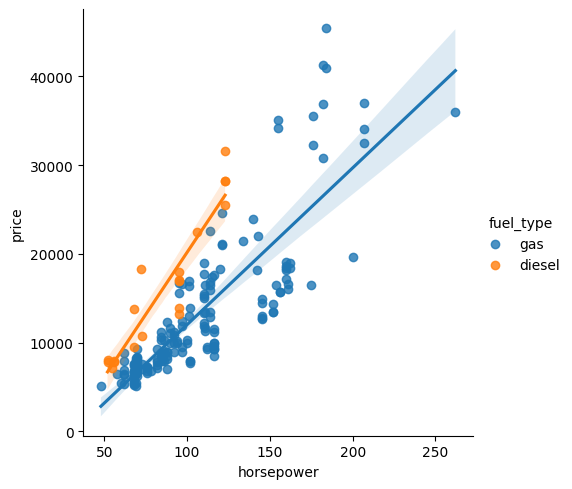

In [43]:
sns.lmplot(x="horsepower", y="price",hue= "fuel_type", data=df);

---

# **Creating Features**

After selecting useful features, now we Transform them into better features.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

accidents = pd.read_csv("../input/accidents.csv")
autos = pd.read_csv("../input/autos.csv")
concrete = pd.read_csv("../input/concrete.csv")
customer = pd.read_csv("../input/customer.csv")

## **Ways of Transforms**

Here are some ways of transformation.

In [15]:
# 1. Mathematical Transforms

autos["stroke_ratio"] = autos["stroke"] / autos["bore"]

In [16]:
# 2. More Mathematical Transformation

autos["displacement"] = (
    np.pi * ((0.5 * autos["bore"]) ** 2) *
    autos["stroke"] *
    autos["num_of_cylinders"]
)

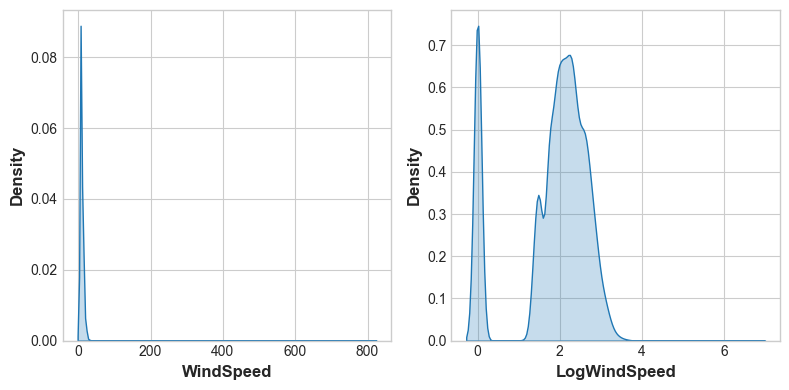

In [17]:
# 3. Log Transformation

accidents["LogWindSpeed"] = np.log1p(accidents["WindSpeed"])

fig, axs = plt.subplots(1, 2, figsize=(8,4))

sns.kdeplot(accidents["WindSpeed"], fill=True, ax=axs[0])
sns.kdeplot(accidents["LogWindSpeed"], fill=True, ax=axs[1])

plt.show()

In [14]:
# 4. Counts

roadway_features = [
    "Amenity", "Bump", "Crossing", "GiveWay",
    "Junction", "NoExit", "Railway", "Roundabout",
    "Station", "Stop", "TrafficCalming", "TrafficSignal"
]

accidents["RoadwayFeatures"] = accidents[roadway_features].sum(axis=1)
accidents[roadway_features + ["RoadwayFeatures"]].head(10)

,Amenity,Bump,Crossing,GiveWay,Junction,NoExit,Railway,Roundabout,Station,Stop,TrafficCalming,TrafficSignal,RoadwayFeatures
0,False,False,False,False,False,False,False,False,False,False,False,False,0
1,False,False,False,False,False,False,False,False,False,False,False,False,0
2,False,False,False,False,False,False,False,False,False,False,False,False,0
3,False,False,False,False,False,False,False,False,False,False,False,False,0
4,False,False,False,False,False,False,False,False,False,False,False,False,0
5,False,False,False,False,True,False,False,False,False,False,False,False,1
6,False,False,False,False,False,False,False,False,False,False,False,False,0
7,False,False,True,False,False,False,False,False,False,False,False,True,2
8,False,False,True,False,False,False,False,False,False,False,False,True,2
9,False,False,False,False,False,False,False,False,False,False,False,False,0


In [13]:
# 5. Counting Using Conditions (gt())

components = [
    "Cement", "BlastFurnaceSlag", "FlyAsh", "Water",
    "Superplasticizer", "CoarseAggregate", "FineAggregate"
]

concrete["Components"] = concrete[components].gt(0).sum(axis=1)
concrete[components + ["Components"]].head(10)

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Components
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,5
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,5
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,5
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,5
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,5
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,5
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,5
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,4


In [12]:
# 6. Breaking Down String Features

customer[["Type", "Level"]] = (
    customer["Policy"]
    .str.split(" ", expand=True)
)

customer[["Policy", "Type", "Level"]].head(10)

,Policy,Type,Level
0,Corporate L3,Corporate,L3
1,Personal L3,Personal,L3
2,Personal L3,Personal,L3
3,Corporate L2,Corporate,L2
4,Personal L1,Personal,L1
5,Personal L3,Personal,L3
6,Corporate L3,Corporate,L3
7,Corporate L3,Corporate,L3
8,Corporate L3,Corporate,L3
9,Special L2,Special,L2


In [19]:
# 7. Combining Features

autos["make_and_style"] = autos["make"] + "_" + autos["body_style"]
autos[["make", "body_style", "make_and_style"]].head()

,make,body_style,make_and_style
0,alfa-romero,convertible,alfa-romero_convertible
1,alfa-romero,convertible,alfa-romero_convertible
2,alfa-romero,hatchback,alfa-romero_hatchback
3,audi,sedan,audi_sedan
4,audi,sedan,audi_sedan


In [21]:
# 8. Group Transforms

customer["AverageIncome"] = (
    customer
    .groupby("State")["Income"]
    .transform("mean")
)

customer[["State", "Income", "AverageIncome"]].head(10)

,State,Income,AverageIncome
0,Washington,56274,38122.733083
1,Arizona,0,37405.402231
2,Nevada,48767,38369.605442
3,California,0,37558.946667
4,Washington,43836,38122.733083
5,Oregon,62902,37557.283353
6,Oregon,55350,37557.283353
7,Arizona,0,37405.402231
8,Oregon,14072,37557.283353
9,Oregon,28812,37557.283353


In [26]:
# 9. Frequency Encoding

customer["StateFreq"] = (
    customer.groupby("State")["State"]
    .transform("count")
    / customer["State"].count()
)

customer[["State","StateFreq"]].head(10)

,State,StateFreq
0,Washington,0.087366
1,Arizona,0.186446
2,Nevada,0.096562
3,California,0.344865
4,Washington,0.087366
5,Oregon,0.284760
6,Oregon,0.284760
7,Arizona,0.186446
8,Oregon,0.284760
9,Oregon,0.284760


### **Data Leakage handling**

Data leakage happens when information from validation/test data is used during training, making evaluation falsely optimistic.

In [31]:
# Split
df_train = customer.sample(frac=0.5, random_state=1)
df_valid = customer.drop(df_train.index)

# Compute only on training
df_train["AverageClaim"] = (
    df_train.groupby("Coverage")["ClaimAmount"]
    .transform("mean")
)

# Merge into validation
df_valid = df_valid.merge(
    df_train[["Coverage", "AverageClaim"]].drop_duplicates(),
    on="Coverage",
    how="left"
)

df_valid[["Coverage", "AverageClaim"]].head(10)

,Coverage,AverageClaim
0,Basic,378.873159
1,Extended,474.878255
2,Premium,645.973865
3,Basic,378.873159
4,Extended,474.878255
5,Basic,378.873159
6,Basic,378.873159
7,Basic,378.873159
8,Basic,378.873159
9,Basic,378.873159
